In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
data = yf.download("AAPL", start= "2020-01-01",end= "2025-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333893,72.394101,71.091199,71.344069,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017815,73.318854,71.565599,71.565599,132079200


In [3]:
data.shape

(1258, 5)

In [4]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [5]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [6]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377786,152.899566,149.680871,151.223470,9.057103e+07
std,41.851999,41.992363,41.629303,41.795805,5.324438e+07
min,54.163692,55.160690,51.324789,55.059301,2.323470e+07
25%,126.279116,127.397085,124.278508,125.724395,5.546825e+07
50%,149.968605,151.709757,148.037172,149.788882,7.628335e+07
75%,175.902035,177.452421,174.337245,175.708257,1.077425e+08
max,257.375610,258.448771,255.994450,256.550893,4.265100e+08


In [7]:
data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [8]:
X = [["Open","High","Low","Volume"]]

y = data["Close"]

In [12]:
X = data[["Open","High","Low","Volume"]]

y = data["Close"]

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state= 42
)

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[ 0.33, 0.34, 0.33,-0. ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[0.42]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[1.66e+09,1.77e+03,3.11e+01,3.05e+01]"


In [15]:
predictions = model.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE =", mae)

MAE = 1.1815033138889004


In [17]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test,predictions)

print("RMSE =",rmse)

RMSE = 1.5805401502505676


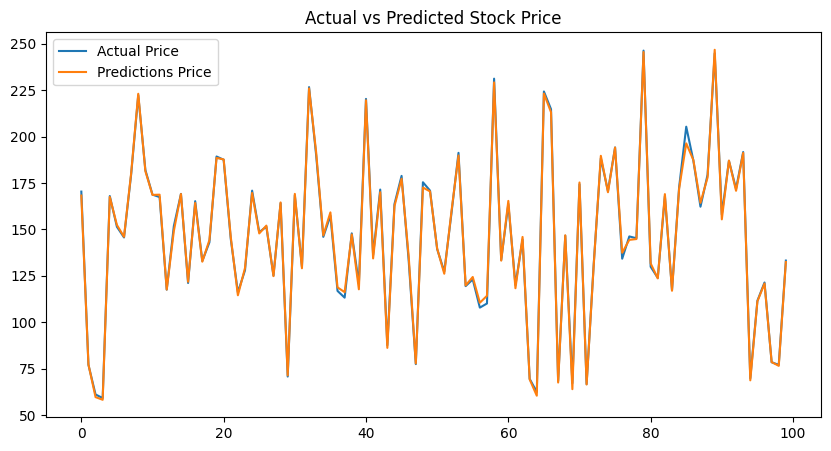

In [18]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:100], label = "Actual Price")

plt.plot(predictions[:100], label = "Predictions Price")

plt.legend()

plt.title("Actual vs Predicted Stock Price")

plt.show()

In [19]:
print(predictions[:10])

[[168.25305379]
 [ 77.21964419]
 [ 59.61776561]
 [ 58.19077532]
 [167.51939106]
 [152.40952257]
 [146.0355181 ]
 [180.24700194]
 [223.12049761]
 [181.41477124]]


In [20]:
print(y_test[:10])

Ticker            AAPL
Date                  
2022-03-24  170.394135
2020-05-28   77.034622
2020-03-17   61.041286
2020-04-02   59.126968
2024-04-09  167.985016
2021-09-08  151.420288
2023-02-27  145.673447
2024-02-28  179.618347
2024-07-19  222.383591
2024-02-15  182.034103
